<a href="https://colab.research.google.com/github/RafihaikalP/BigData26_A_2411532002_Rafi-Haikal-Pratama/blob/main/Praktikum%201/BD_A_P01_2411532002_Rafi_Haikal_Pratama_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TUGAS PRATIKUM**

## 1. Persiapan Lingkungan


In [4]:
import sys, platform, multiprocessing, os, time, gc
print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib", "psutil"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")


Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0
psutil     : 5.9.5


In [5]:
# Pemeriksaan RAM, disk, dan Java di Google Colab
!free -h
!df -h /content
!java -version


               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       8.5Gi       2.1Mi       3.3Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


## 2. Menghubungkan Google Drive dan Menyiapkan Folder


In [6]:
from google.colab import drive
drive.mount("/content/drive")

DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1/Juli2023"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print("Folder hasil:", DIR_SIMPAN)
print("Isi folder:", os.listdir(DIR_SIMPAN))


Mounted at /content/drive
Folder hasil: /content/drive/MyDrive/BigData/Praktikum1/Juli2023
Isi folder: []


## 3. Menyiapkan Pengukuran Waktu dan Memori


In [7]:
import psutil
proses = psutil.Process(os.getpid())
catatan_juli = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur_juli(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan_juli.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta, 1)
    })
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil


## 4. Mengunduh Dataset Juli 2023 dan Inspeksi Metadata


In [8]:
import urllib.request
import pyarrow.parquet as pq

URL_JULI = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"
PATH_JULI = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

if not os.path.exists(PATH_JULI):
    ukur_juli("unduh dataset Juli 2023", lambda: urllib.request.urlretrieve(URL_JULI, PATH_JULI))

print("Ukuran file:", round(os.path.getsize(PATH_JULI) / 1024**2, 1), "MB")


[unduh dataset Juli 2023] 0.86 s | RSS +1.0 MB
Ukuran file: 46.1 MB


In [9]:
meta_juli = pq.ParquetFile(PATH_JULI).metadata
print("Jumlah baris   :", f"{meta_juli.num_rows:,}")
print("Jumlah kolom   :", meta_juli.num_columns)
print("Row group      :", meta_juli.num_row_groups)
print("Nama kolom     :", pq.ParquetFile(PATH_JULI).schema.names)


Jumlah baris   : 2,907,108
Jumlah kolom   : 19
Row group      : 1
Nama kolom     : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


## 5. Memuat Kolom yang Diperlukan dan Mengukur Memori


In [10]:
import pandas as pd

KOLOM_JULI = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "payment_type",
    "fare_amount", "tip_amount", "total_amount"
]

penuh_juli = ukur_juli("baca semua kolom Juli", lambda: pd.read_parquet(PATH_JULI))
print("Dimensi:", penuh_juli.shape)
print("Memori :", round(penuh_juli.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh_juli
gc.collect()

df_juli = ukur_juli(
    "baca kolom terpilih Juli",
    lambda: pd.read_parquet(PATH_JULI, columns=KOLOM_JULI)
)
print("Dimensi:", df_juli.shape)
print("Memori :", round(df_juli.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df_juli.head()


[baca semua kolom Juli] 1.68 s | RSS +482.0 MB
Dimensi: (2907108, 19)
Memori : 502.5 MB
[baca kolom terpilih Juli] 0.58 s | RSS +133.2 MB
Dimensi: (2907108, 8)
Memori : 177.4 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-07-01 00:29:59,2023-07-01 00:40:15,1.0,1.80,1,12.1,5.10,22.20
1,2023-07-01 00:03:25,2023-07-01 00:23:44,1.0,2.31,2,19.1,0.00,24.10
2,2023-07-01 00:38:29,2023-07-01 00:48:53,1.0,2.36,1,13.5,3.70,22.20
3,2023-07-01 00:14:16,2023-07-01 00:29:13,1.0,4.36,1,19.8,4.96,29.76
4,2023-07-01 00:11:15,2023-07-01 00:20:47,0.0,1.60,1,11.4,3.25,19.65


In [11]:
df_juli.info(memory_usage="deep")
df_juli.memory_usage(deep=True).sort_values(ascending=False) / 1024**2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2907108 entries, 0 to 2907107
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 177.4 MB


,0
tpep_pickup_datetime,22.179474
payment_type,22.179474
tpep_dropoff_datetime,22.179474
passenger_count,22.179474
trip_distance,22.179474
tip_amount,22.179474
fare_amount,22.179474
total_amount,22.179474
Index,0.000126


In [12]:
sebelum_juli = df_juli.memory_usage(deep=True).sum() / 1024**2

df_juli["passenger_count"] = pd.to_numeric(df_juli["passenger_count"], downcast="float")
df_juli["payment_type"] = df_juli["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df_juli[kol] = pd.to_numeric(df_juli[kol], downcast="float")

sesudah_juli = df_juli.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum_juli:.1f} MB -> {sesudah_juli:.1f} MB")
print(f"Penghematan memori: {100*(1-sesudah_juli/sebelum_juli):.1f}%")
print(df_juli.dtypes)


177.4 MB -> 113.7 MB
Penghematan memori: 35.9%
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float32
trip_distance                   float64
payment_type                   category
fare_amount                     float32
tip_amount                      float32
total_amount                    float32
dtype: object


## 6. Pemeriksaan Kualitas dan Pembersihan Data Juli


In [13]:
df_juli["durasi_menit"] = (
    df_juli["tpep_dropoff_datetime"] - df_juli["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print(df_juli[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df_juli.isna().sum())

anomali_juli = {
    "jarak <= 0": (df_juli["trip_distance"] <= 0).sum(),
    "durasi <= 0": (df_juli["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df_juli["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df_juli["total_amount"] <= 0).sum(),
}

for k, v in anomali_juli.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df_juli):.2f}%)")


       trip_distance  durasi_menit  total_amount
count   2.907108e+06  2.907108e+06  2.907108e+06
mean    4.489381e+00  1.707664e+01  2.856786e+01
std     2.578832e+02  4.099461e+01  2.446845e+01
min     0.000000e+00 -5.711667e+01 -6.223000e+02
25%     1.060000e+00  7.466667e+00  1.570000e+01
50%     1.810000e+00  1.240000e+01  2.090000e+01
75%     3.580000e+00  2.033333e+01  3.080000e+01
max     1.919450e+05  7.348833e+03  1.079450e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          85086
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 49,790 baris (1.71%)
durasi <= 0           : 1,395 baris (0.05%)
durasi > 180 menit    : 2,760 baris (0.09%)
total_amount <= 0     : 31,240 baris (1.07%)


In [14]:
layak_juli = (
    (df_juli["trip_distance"] > 0) &
    (df_juli["trip_distance"] < 100) &
    df_juli["durasi_menit"].between(1, 180) &
    (df_juli["total_amount"] > 0)
)

bersih_juli = df_juli.loc[layak_juli].copy()
print(
    f"{len(df_juli):,} baris -> {len(bersih_juli):,} baris "
    f"(dibuang {len(df_juli)-len(bersih_juli):,})"
)


2,907,108 baris -> 2,817,657 baris (dibuang 89,451)


## 7. Chunking untuk Pemrosesan Bertahap


In [15]:
CSV_JULI = os.path.join(DIR_KERJA, "trips_juli_2023.csv")
ukur_juli("tulis CSV Juli", lambda: bersih_juli.to_csv(CSV_JULI, index=False))

print("Parquet:", round(os.path.getsize(PATH_JULI) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV_JULI) / 1024**2, 1), "MB")


[tulis CSV Juli] 35.80 s | RSS +5.2 MB
Parquet: 46.1 MB
CSV    : 213.6 MB


In [16]:
def agregasi_bertahap_juli(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}

    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )

    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()

        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (
                n + len(sub),
                nilai + sub["total_amount"].sum()
            )

    return jumlah_baris, total_nilai, per_jam

baris_juli, total_juli, per_jam_juli = ukur_juli(
    "agregasi chunking Juli",
    lambda: agregasi_bertahap_juli(CSV_JULI)
)

print(f"{baris_juli:,} baris | rata-rata total_amount = {total_juli/baris_juli:.2f}")


[agregasi chunking Juli] 3.68 s | RSS +29.9 MB
2,817,657 baris | rata-rata total_amount = 29.04


## 8. Agregasi Final Dataset Juli 2023


In [17]:
bersih_juli["jam"] = bersih_juli["tpep_pickup_datetime"].dt.hour

agregasi_juli = (
    bersih_juli
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean"),
        median_tarif=("total_amount", "median")
    )
    .round(2)
    .reset_index()
)

agregasi_juli.to_csv(
    f"{DIR_SIMPAN}/agregasi_per_jam_juli.csv",
    index=False
)
agregasi_juli.to_parquet(
    f"{DIR_SIMPAN}/agregasi_per_jam_juli.parquet",
    index=False
)
pd.DataFrame(catatan_juli).to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja_juli.csv",
    index=False
)

agregasi_juli


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


## 9. Visualisasi Distribusi Perjalanan per Jam


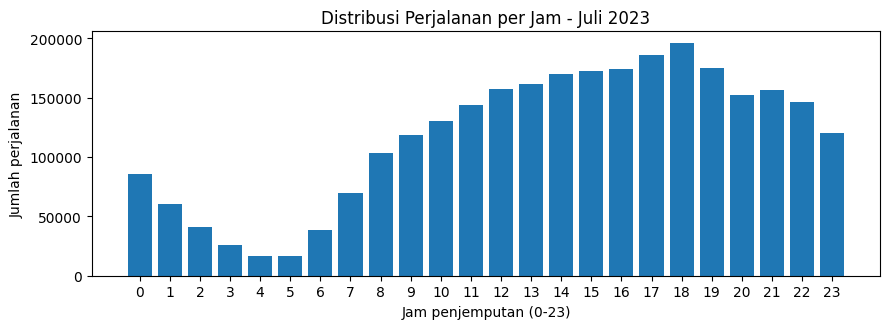

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_juli["jam"], agregasi_juli["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi Perjalanan per Jam - Juli 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(
    f"{DIR_SIMPAN}/distribusi_per_jam_juli.png",
    dpi=150
)
plt.show()


## 10. Studi Kasus Penjadwalan Armada Juli 2023


In [19]:
bersih_juli["hari"] = bersih_juli["tpep_pickup_datetime"].dt.day_name()
bersih_juli_unused = None


In [20]:
bersih_juli["akhir_pekan"] = bersih_juli["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih_juli["tarif_per_menit"] = (
    bersih_juli["total_amount"] / bersih_juli["durasi_menit"]
).round(3)

ringkas_juli = (
    bersih_juli
    .groupby(["akhir_pekan", "jam"])
    .agg(
        jumlah=("total_amount", "size"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif_per_menit=("tarif_per_menit", "mean")
    )
    .round(2)
)

ringkas_juli.head(12)


jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     41696        14.96                  2.44
            1     22724        14.11                  2.52
            2     12375        13.52                  2.54
            3      7419        14.07                  2.64
            4      6795        16.32                  2.79
            5     12182        15.53                  2.77
            6     30991        14.48                  2.39
            7     58350        14.69                  2.15
            8     86890        15.72                  1.94
            9     92934        16.43                  1.85
            10    96232        16.92                  1.84
            11   102981        17.53                  1.80

## 11. Latihan Tambahan


### 11.1 Lima Perjalanan dengan Jarak Terjauh


In [21]:
top5_juli = bersih_juli.nlargest(5, "trip_distance")
top5_juli


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1621787,2023-07-19 16:38:10,2023-07-19 18:58:45,1.0,99.62,2,680.599976,0.0,684.599976,140.583333,16,Wednesday,False,4.870
968644,2023-07-12 20:38:14,2023-07-12 22:13:03,3.0,99.21,1,224.000000,0.0,225.000000,94.816667,20,Wednesday,False,2.373
1227438,2023-07-15 12:24:32,2023-07-15 15:05:44,2.0,99.11,2,325.000000,0.0,327.750000,161.200000,12,Saturday,True,2.033
2777070,2023-07-31 14:03:53,2023-07-31 15:55:46,4.0,98.85,1,350.000000,0.0,410.250000,111.883333,14,Monday,False,3.667
1235113,2023-07-15 13:12:34,2023-07-15 15:22:35,3.0,98.65,2,595.200012,0.0,619.250000,130.016667,13,Saturday,True,4.763


### 11.2 Perbandingan Ukuran Chunk


In [22]:
for ukuran_chunk in [100_000, 1_000_000]:
    ukur_juli(
        f"chunking Juli chunksize={ukuran_chunk}",
        lambda uc=ukuran_chunk: agregasi_bertahap_juli(CSV_JULI, ukuran_chunk=uc)
    )


[chunking Juli chunksize=100000] 4.36 s | RSS +51.1 MB
[chunking Juli chunksize=1000000] 3.70 s | RSS +32.1 MB


### 11.3 Persentase Tip per Metode Pembayaran


In [23]:
import numpy as np

bersih_juli["persen_tip"] = np.where(
    bersih_juli["fare_amount"] > 0,
    bersih_juli["tip_amount"] / bersih_juli["fare_amount"] * 100,
    np.nan
)

rata_tip_per_metode_juli = (
    bersih_juli.groupby("payment_type")["persen_tip"]
    .mean()
    .round(2)
)
rata_tip_per_metode_juli


/tmp/ipykernel_4059/682464538.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bersih_juli.groupby("payment_type")["persen_tip"]


,persen_tip
payment_type,
0,17.190001
1,27.889999
2,0.000000
3,0.030000
4,0.060000


### 11.4 Perbandingan Kompresi Parquet


In [24]:
for kompresi in ["snappy", "gzip"]:
    path_out = f"{DIR_KERJA}/bersih_juli_{kompresi}.parquet"
    t0 = time.perf_counter()
    bersih_juli.to_parquet(path_out, index=False, compression=kompresi)
    detik = time.perf_counter() - t0
    ukuran = os.path.getsize(path_out) / 1024**2
    print(f"{kompresi:7s}: {ukuran:.1f} MB | {detik:.2f} s")


snappy : 60.3 MB | 1.62 s
gzip   : 48.6 MB | 38.97 s


## 12. Ringkasan Hasil Kinerja

Tabel berikut menampilkan pengukuran waktu dan pertumbuhan RSS yang tercatat selama notebook dijalankan.


In [25]:
tabel_kinerja_juli = pd.DataFrame(catatan_juli)
tabel_kinerja_juli


,langkah,detik,delta_rss_mb
0,unduh dataset Juli 2023,0.86,1.0
1,baca semua kolom Juli,1.68,482.0
2,baca kolom terpilih Juli,0.58,133.2
3,tulis CSV Juli,35.80,5.2
4,agregasi chunking Juli,3.68,29.9
5,chunking Juli chunksize=100000,4.36,51.1
6,chunking Juli chunksize=1000000,3.70,32.1


# **Perbandingan bulan januari dengan juli**

Mengunduh yellow_tripdata_2023-01.parquet ...
Mengunduh yellow_tripdata_2023-07.parquet ...
Python: 3.13.15
CPU cores: 2
Folder output: /content/Praktikum01
Baris awal Januari : 3066766
Baris bersih Januari: 2986911
Baris bersih Juli    : 2817657


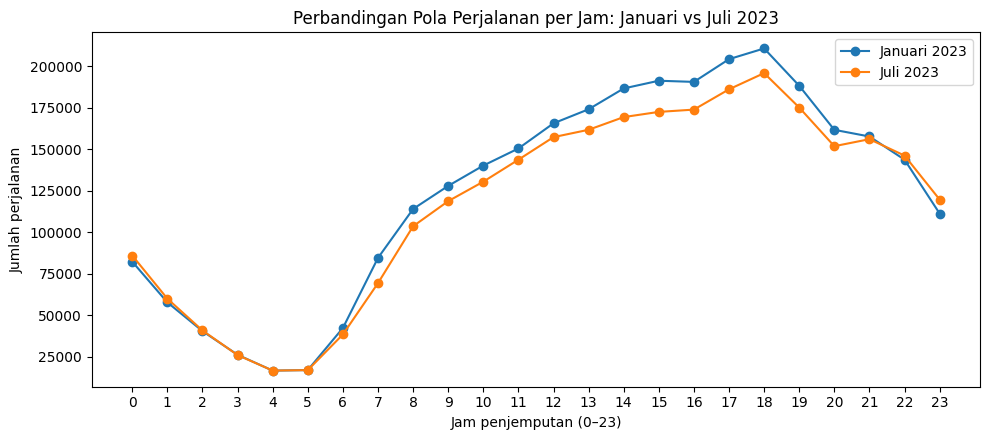

{'langkah': 'baca Januari kolom terpilih', 'detik': 0.548, 'delta_rss_mb': 187.6}
{'langkah': 'baca Juli kolom terpilih', 'detik': 0.339, 'delta_rss_mb': 179.13}
{'langkah': 'tulis Januari CSV', 'detik': 47.24, 'delta_rss_mb': 0.0}
{'langkah': 'tulis Juli CSV', 'detik': 41.915, 'delta_rss_mb': 0.0}
{'langkah': 'agregasi Januari', 'detik': 0.15, 'delta_rss_mb': 0.0}
{'langkah': 'agregasi Juli', 'detik': 0.145, 'delta_rss_mb': 0.0}
Langkah berdasarkan waktu terbesar:
langkah         tulis Januari CSV
detik                       47.24
delta_rss_mb                  0.0
Name: 2, dtype: object

Usulan perubahan konkret:
Gunakan pembacaan kolom yang lebih selektif dan hindari konversi/tulisan ulang data yang tidak diperlukan. Untuk agregasi besar, pertahankan operasi pada format Parquet atau gunakan chunking saat harus membaca CSV.
{
  "Volume": {
    "rows_januari": 3066766,
    "rows_juli": 2907108,
    "size_mb_januari": 45.46,
    "size_mb_juli": 46.12
  },
  "Velocity": {
    "observasi"

In [27]:
# Script pendukung Tugas Praktikum Big Data Q2-Q5
# Jalankan di Google Colab/Jupyter.

# Instalasi library yang dibutuhkan
!pip -q install pyarrow pandas matplotlib psutil

import os, time, platform, multiprocessing, urllib.request, json
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import psutil

BASE = Path("/content/Praktikum01")
BASE.mkdir(parents=True, exist_ok=True)

URL_JAN = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_JUL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"

PATH_JAN = BASE / "yellow_tripdata_2023-01.parquet"
PATH_JUL = BASE / "yellow_tripdata_2023-07.parquet"

CSV_JAN = BASE / "jan_clean.csv"
CSV_JUL = BASE / "juli_clean.csv"

def download_if_needed(url, path):
    if not path.exists():
        print(f"Mengunduh {path.name} ...")
        urllib.request.urlretrieve(url, path)
    else:
        print(f"Sudah tersedia: {path.name}")

download_if_needed(URL_JAN, PATH_JAN)
download_if_needed(URL_JUL, PATH_JUL)

print("Python:", platform.python_version())
print("CPU cores:", multiprocessing.cpu_count())
print("Folder output:", BASE)


def metadata_parquet(path):
    meta = pq.ParquetFile(path).metadata
    return {
        "file": path.name,
        "rows": meta.num_rows,
        "columns": meta.num_columns,
        "size_mb": round(path.stat().st_size / 1024**2, 2),
        "column_names": pq.ParquetFile(path).schema.names
    }

meta_jan = metadata_parquet(PATH_JAN)
meta_jul = metadata_parquet(PATH_JUL)

pd.DataFrame([
    {k: v for k, v in meta_jan.items() if k != "column_names"},
    {k: v for k, v in meta_jul.items() if k != "column_names"},
])


# Kolom yang diperlukan untuk analisis pola per jam
COLS = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "payment_type",
    "fare_amount", "tip_amount", "total_amount"
]

def prepare_month(path, month_label):
    df = pd.read_parquet(path, columns=COLS)
    df["durasi_menit"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    layak = (
        (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
        df["durasi_menit"].between(1, 180) &
        (df["total_amount"] > 0)
    )
    clean = df.loc[layak].copy()
    clean["jam"] = clean["tpep_pickup_datetime"].dt.hour
    clean["bulan"] = month_label
    return clean

jan = prepare_month(PATH_JAN, "Januari 2023")
juli = prepare_month(PATH_JUL, "Juli 2023")

print("Baris awal Januari :", len(pd.read_parquet(PATH_JAN, columns=["total_amount"])))
print("Baris bersih Januari:", len(jan))
print("Baris bersih Juli    :", len(juli))


def hourly_summary(df):
    return (
        df.groupby("jam")
          .agg(
              jumlah_perjalanan=("total_amount", "size"),
              rata_jarak=("trip_distance", "mean"),
              rata_durasi=("durasi_menit", "mean"),
              rata_tarif=("total_amount", "mean")
          )
          .round(2)
          .reset_index()
    )

agg_jan = hourly_summary(jan).rename(columns={
    "jumlah_perjalanan": "jumlah_jan",
    "rata_jarak": "rata_jarak_jan",
    "rata_durasi": "rata_durasi_jan",
    "rata_tarif": "rata_tarif_jan"
})

agg_jul = hourly_summary(juli).rename(columns={
    "jumlah_perjalanan": "jumlah_juli",
    "rata_jarak": "rata_jarak_juli",
    "rata_durasi": "rata_durasi_juli",
    "rata_tarif": "rata_tarif_juli"
})

bandingkan = (
    pd.DataFrame({"jam": range(24)})
      .merge(agg_jan, on="jam", how="left")
      .merge(agg_jul, on="jam", how="left")
      .fillna(0)
)

bandingkan["selisih_jumlah"] = (
    bandingkan["jumlah_juli"] - bandingkan["jumlah_jan"]
)

bandingkan


# Simpan tabel perbandingan
bandingkan.to_csv(BASE / "perbandingan_januari_vs_juli_per_jam.csv", index=False)

# Grafik perbandingan jumlah perjalanan per jam
plt.figure(figsize=(10, 4.5))
plt.plot(bandingkan["jam"], bandingkan["jumlah_jan"], marker="o", label="Januari 2023")
plt.plot(bandingkan["jam"], bandingkan["jumlah_juli"], marker="o", label="Juli 2023")
plt.xlabel("Jam penjemputan (0–23)")
plt.ylabel("Jumlah perjalanan")
plt.title("Perbandingan Pola Perjalanan per Jam: Januari vs Juli 2023")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.savefig(BASE / "perbandingan_januari_vs_juli_per_jam.png", dpi=150)
plt.show()


process = psutil.Process(os.getpid())
kinerja = []

def ukur(label, fungsi):
    m0 = process.memory_info().rss / 1024**2
    t0 = time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    m1 = process.memory_info().rss / 1024**2
    rec = {
        "langkah": label,
        "detik": round(detik, 3),
        "delta_rss_mb": round(m1 - m0, 2)
    }
    kinerja.append(rec)
    print(rec)
    return hasil

# Pengukuran contoh yang representatif untuk tugas
_ = ukur("baca Januari kolom terpilih", lambda: pd.read_parquet(PATH_JAN, columns=COLS))
_ = ukur("baca Juli kolom terpilih", lambda: pd.read_parquet(PATH_JUL, columns=COLS))

# Tulis CSV sebagai beban I/O
_ = ukur("tulis Januari CSV", lambda: jan.to_csv(CSV_JAN, index=False))
_ = ukur("tulis Juli CSV", lambda: juli.to_csv(CSV_JUL, index=False))

# Agregasi per jam
_ = ukur("agregasi Januari", lambda: hourly_summary(jan))
_ = ukur("agregasi Juli", lambda: hourly_summary(juli))

kinerja_df = pd.DataFrame(kinerja)
kinerja_df.to_csv(BASE / "pengukuran_kinerja_q2_q5.csv", index=False)
kinerja_df


# Cari langkah dengan waktu eksekusi terbesar
termahal = kinerja_df.loc[kinerja_df["detik"].idxmax()]
print("Langkah berdasarkan waktu terbesar:")
print(termahal)

print("\nUsulan perubahan konkret:")
print("Gunakan pembacaan kolom yang lebih selektif dan hindari konversi/tulisan ulang data "
      "yang tidak diperlukan. Untuk agregasi besar, pertahankan operasi pada format Parquet "
      "atau gunakan chunking saat harus membaca CSV.")


# Ringkasan angka untuk refleksi 5V
raw_jan_rows = meta_jan["rows"]
raw_jul_rows = meta_jul["rows"]
clean_jan_rows = len(jan)
clean_jul_rows = len(juli)

summary_5v = {
    "Volume": {
        "rows_januari": raw_jan_rows,
        "rows_juli": raw_jul_rows,
        "size_mb_januari": meta_jan["size_mb"],
        "size_mb_juli": meta_jul["size_mb"],
    },
    "Velocity": {
        "observasi": "Tidak diukur secara streaming karena dataset bersifat historis"
    },
    "Variety": {
        "format": "Parquet",
        "jumlah_kolom": meta_jan["columns"]
    },
    "Veracity": {
        "bersih_januari": clean_jan_rows,
        "dibuang_januari": raw_jan_rows - clean_jan_rows,
        "bersih_juli": clean_jul_rows,
        "dibuang_juli": raw_jul_rows - clean_jul_rows
    },
    "Value": {
        "indikator": "pola jumlah perjalanan per jam dan rata-rata tarif/jarak/durasi"
    }
}

print(json.dumps(summary_5v, indent=2, ensure_ascii=False))
with open(BASE / "refleksi_5v.json", "w", encoding="utf-8") as f:
    json.dump(summary_5v, f, indent=2, ensure_ascii=False)
